# The Slow Bell \U0001F514
### Returns are fat-tailed daily and nearly normal annually. How long is "annually"?

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The central limit theorem is the closest thing finance has to a law of nature: add up enough
independent draws and you get a bell curve. Monthly returns are sums of twenty-one daily ones.
So the fat tails should fade as you zoom out — and they do. The question is how fast, and the
answer turns on the word *independent*.

> \U0001F4D3 **This is the plain-language layer.** The exact *k₁/n* benchmark, the tail index and
> the test-power simulation are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do returns get more normal as the horizon grows? | Yes, genuinely. |
| As fast as the textbook says? | No — several times slower. |
| Why not? | Volatility clusters, so the draws are not independent. |
| Are annual returns normal? | Close-ish. But with 32 observations, nobody can really tell. |

## 1 · What "fat tails" means, at a glance

In [2]:
from slowbell import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
r = assets[data.EQUITY]
prof = st.convergence_profile(r)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions, "
      f"{r.index[0].date()} -> {r.index[-1].date()}")
print(prof[["n", "excess_kurtosis", "iid_prediction", "kurtosis_vs_iid",
            "ratio_3sig"]].round(3).to_string())

as-of 2026-06-30 | SPY: 7,764 sessions, 1993-02-01 -> 2026-06-30
            n  excess_kurtosis  iid_prediction  kurtosis_vs_iid  ratio_3sig
horizon                                                                    
1        7764          10.5680         10.5680           1.0000      5.6290
5        1552           8.8550          2.1140           4.1900      4.0570
10        776          10.7360          1.0570          10.1590      5.7280
21        369           5.6070          0.5030          11.1430      7.0270
63        123          25.8670          0.1680         154.2050      3.0110
126        61          15.8070          0.0840         188.4570      6.0720
252        30           6.7300          0.0420         160.4790         NaN


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


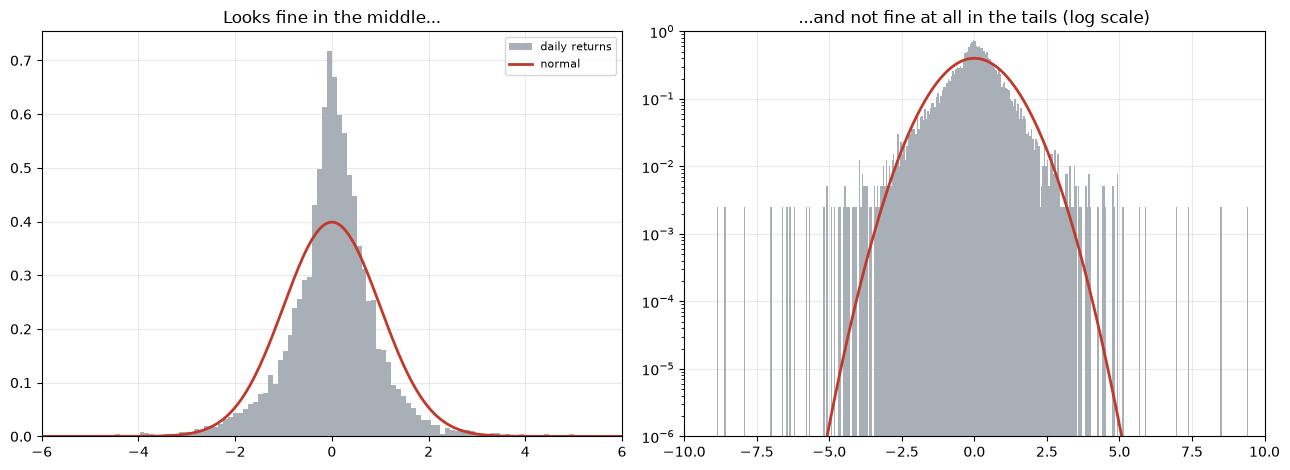

3-sigma days: 118 observed, 21.0 expected under a normal (6x too many)
4-sigma days: 48 observed, 0.5 expected under a normal (98x too many)
5-sigma days: 21 observed, 0.0 expected under a normal (4718x too many)


In [3]:
z = st.standardise(st.aggregate(r, 1))
grid = np.linspace(-6, 6, 400)
normal_pdf = np.exp(-grid ** 2 / 2) / np.sqrt(2 * np.pi)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(z, bins=200, density=True, color="#8b949e", alpha=0.75, label="daily returns")
axes[0].plot(grid, normal_pdf, lw=2, color="#c0392b", label="normal")
axes[0].set_xlim(-6, 6); axes[0].legend(fontsize=8)
axes[0].set_title("Looks fine in the middle...")
axes[1].hist(z, bins=400, density=True, color="#8b949e", alpha=0.75)
axes[1].plot(grid, normal_pdf, lw=2, color="#c0392b")
axes[1].set_yscale("log"); axes[1].set_xlim(-10, 10); axes[1].set_ylim(1e-6, 1)
axes[1].set_title("...and not fine at all in the tails (log scale)")
plt.tight_layout(); plt.show()
tr = st.tail_ratio(st.aggregate(r, 1))
for s in (3, 4, 5):
    print(f"{s}-sigma days: {tr[f'count_{s}sig']} observed, "
          f"{tr[f'exp_{s}sig'] * tr['n']:.1f} expected under a normal "
          f"({tr[f'ratio_{s}sig']:.0f}x too many)")

## 2 · Zooming out

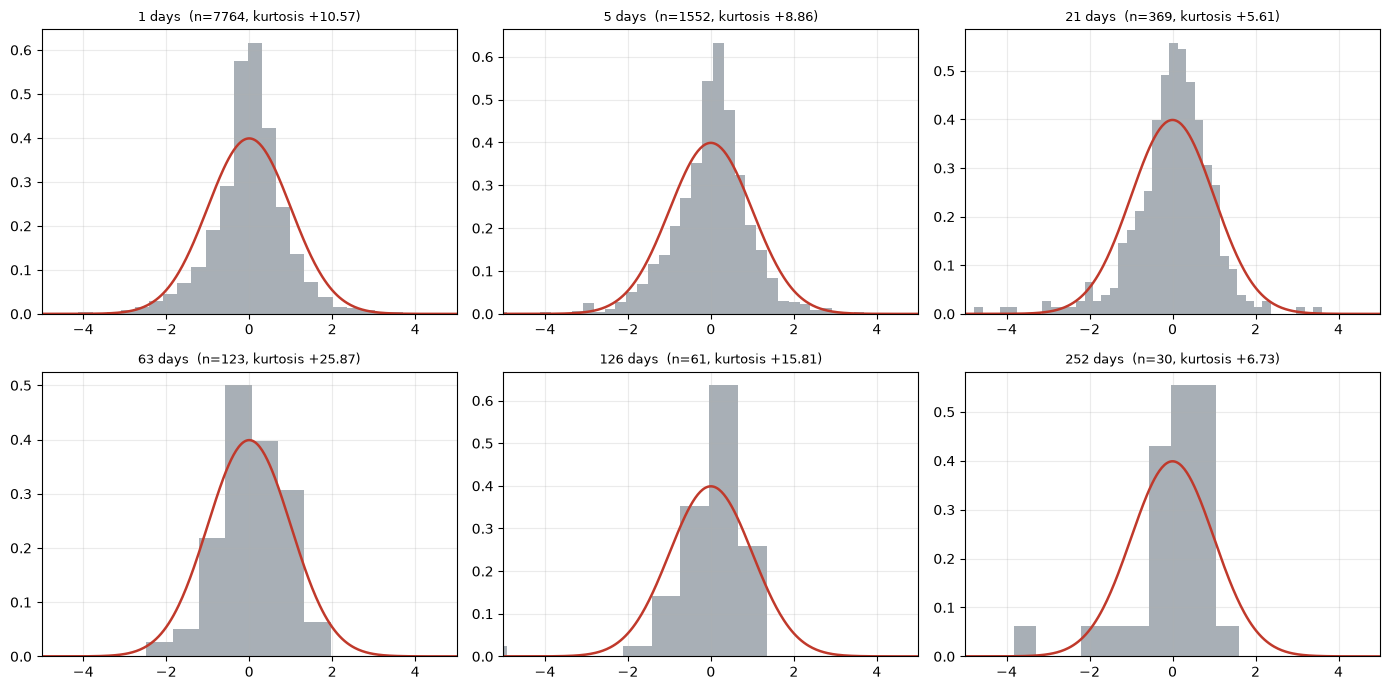

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, hz in zip(axes.ravel(), (1, 5, 21, 63, 126, 252)):
    x = st.aggregate(r, hz)
    if len(x) < 20:
        ax.axis("off"); continue
    zz = st.standardise(x)
    ax.hist(zz, bins=min(60, max(10, len(zz) // 8)), density=True, color="#8b949e",
            alpha=0.75)
    ax.plot(grid, normal_pdf, lw=1.8, color="#c0392b")
    ax.set_xlim(-5, 5)
    ax.set_title(f"{hz} days  (n={len(x)}, kurtosis {st.excess_kurtosis(x):+.2f})",
                 fontsize=9)
plt.tight_layout(); plt.show()

> \U0001F52C **For the quants.** Note the sample sizes in the titles. The last panel is a
> histogram of about thirty numbers, and a histogram of thirty numbers looks roughly normal
> almost regardless of what generated it.

## 3 · The race against the textbook

Here is the part that makes this measurable rather than impressionistic. For **independent**
draws, the excess kurtosis after summing *n* of them is exactly *k₁/n*. No approximation. So
we can draw the textbook's prediction as a line and see how far behind the tape runs.

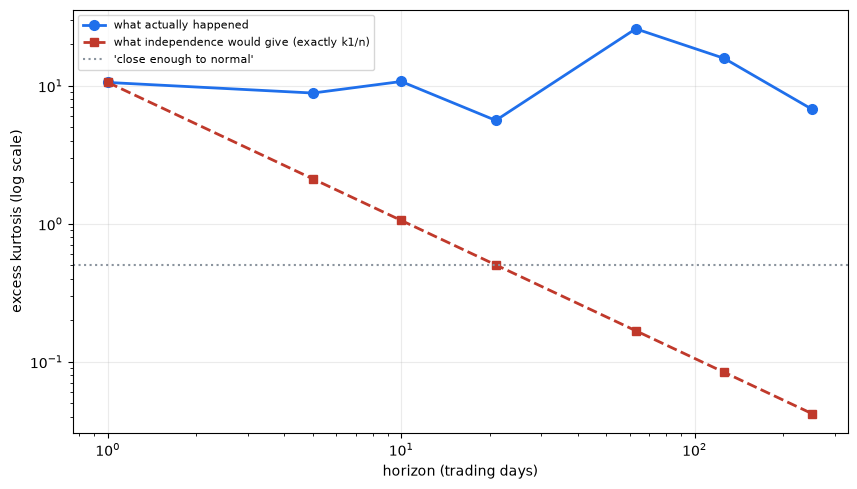

fitted decay: kurtosis ~ horizon^(--0.04)
independence says the exponent should be exactly 1.00
t against that: -8.77


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.loglog(prof.index, prof["excess_kurtosis"], "o-", lw=2, ms=7, color="#1f6feb",
          label="what actually happened")
ax.loglog(prof.index, prof["iid_prediction"], "s--", lw=2, ms=6, color="#c0392b",
          label="what independence would give (exactly k1/n)")
ax.axhline(0.5, color="#8b949e", ls=":", lw=1.5, label="'close enough to normal'")
ax.set_xlabel("horizon (trading days)"); ax.set_ylabel("excess kurtosis (log scale)")
ax.legend(fontsize=8)
plt.show()
fit = st.fit_decay_rate(prof)
print(f"fitted decay: kurtosis ~ horizon^(-{fit['exponent']:.2f})")
print(f"independence says the exponent should be exactly 1.00")
print(f"t against that: {fit['t_vs_one']:+.2f}")

## 4 · Why the tape is slower

Because the days are not independent. Volatility clusters: a wild day is followed by a wild day.
When you add up twenty-one days you are not adding twenty-one independent draws, you are adding
twenty-one draws that mostly agree about how wild the month is.

In [6]:
rows = []
for dft, clus, tag in ((1000, 0.0, "normal, independent"),
                       (4.0, 0.0, "fat tails, independent"),
                       (1000, 0.99, "normal, clustered"),
                       (4.0, 0.99, "fat tails, clustered")):
    sim = st.synthetic_returns(n=len(r), df_t=dft, clustering=clus)
    p = st.convergence_profile(sim)
    rows.append({"world": tag, "1 day": p.loc[1, "excess_kurtosis"],
                 "21 days": p.loc[21, "excess_kurtosis"],
                 "252 days": p.loc[252, "excess_kurtosis"] if 252 in p.index else np.nan})
d = pd.DataFrame(rows).set_index("world")
print(d.round(3).to_string())
print(f"\nthe real tape: {prof.loc[1, 'excess_kurtosis']:.2f} -> "
      f"{prof.loc[21, 'excess_kurtosis']:.2f} -> "
      f"{prof.loc[252, 'excess_kurtosis']:.3f}")

c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


                          1 day  21 days  252 days
world                                             
normal, independent      0.0660   0.0850   -0.7030
fat tails, independent   5.5540   0.2850    0.3140
normal, clustered       37.8390  93.9190    9.6090
fat tails, clustered   464.0300 164.4550   24.4290

the real tape: 10.57 -> 5.61 -> 6.730


c:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\991-aggregational-gaussianity\slowbell\strategy.py:110: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res = stats.anderson(v, dist="norm")


Compare rows two and four. Same fat tails. Only the clustering differs — and that is what turns
a fast convergence into a slow one.

## 5 · The part where we run out of data

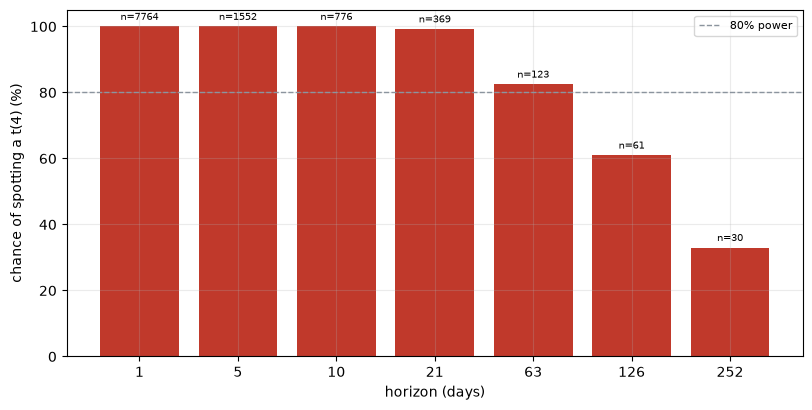

In [7]:
n_by_h = {int(hz): int(row["n"]) for hz, row in prof.iterrows()}
pw = st.power_of_normality_tests(n_by_h, true_df=4.0, n_sims=400)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar([str(i) for i in pw.index], pw["power_vs_t4"] * 100, color="#c0392b")
ax.axhline(80, ls="--", color="#8b949e", lw=1, label="80% power")
ax.set_xlabel("horizon (days)"); ax.set_ylabel("chance of spotting a t(4) (%)")
ax.legend(fontsize=8)
for i, (hz, rr) in enumerate(pw.iterrows()):
    ax.text(i, rr["power_vs_t4"] * 100 + 2, f"n={int(rr['n_obs'])}", ha="center", fontsize=7)
plt.show()

At a one-year horizon we have about thirty observations, and with thirty observations a
normality test cannot reliably tell a *t*(4) from a bell curve. So "annual returns pass the
test" is not much of a finding.

## 6 · The verdict

**Signal: Confirmed.** For SPY over 7,764 sessions, excess kurtosis falls from **10.6 at one day to 6.73 at 252 days** — so the stylised fact is real. But it is not the central limit theorem's rate. For independent draws the decay is exactly ``k₁/n``, which would put the 252-day kurtosis at **0.042**; the tape delivers 160× that. Fitting `kurtosis ~ horizon^(−b)` gives **b = -0.04** (se 0.12) against the i.i.d. value of 1.00, *t* = **-8.77**. The Hill tail index is **2.99** — above 2, so the variance exists and the theorem does apply, but below 4, meaning the kurtosis itself may not exist and every kurtosis number above is an unstable statistic rather than an estimate.

**Tradability: Mirage.** The practical question is when normal arithmetic becomes safe. Excess kurtosis first drops below 0.5 at **None days** against the 63 days independence would have predicted — a slowdown of **nan×**. At the longest horizon measured, 3-sigma moves still arrive **nan× more often** than a normal says. And a warning about the tests: at 252 days there are only 30 non-overlapping observations, where Jarque-Bera has about **33% power** against a *t*(4). A passing normality test at long horizons is mostly evidence that the sample is small.

## 7 · Going further \U0001F6AA

- **Stop using kurtosis.** If the tail index is below 4 the population kurtosis is infinite and
  the sample version does not estimate anything. Tail-index estimates and quantile ratios are
  better-behaved.
- **Model the clustering.** A GARCH fit gives the aggregation rate analytically (Drost & Nijman
  1993) instead of measuring it horizon by horizon.
- **More history, not more overlap.** Overlapping windows multiply rows without multiplying
  information; the only cure for thirty annual observations is more decades.